In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [41]:
def spline(x, y, c, x0):
    def find_index(x, x0):
        li = 0
        ri = len(x) - 1
        while ri - li > 1:
            m = (ri + li) // 2
            if x0 < x[m]:
                ri = m
            else:
                li = m
        return li
    i = find_index(x, x0)
    h = x[i+1] - x[i]
    y0 = ((x[i+1] - x0)**3 / h - (x[i+1]- x0) * h) * c[i] / 6.0 \
        + ((x0 - x[i])**3 / h - (x0 - x[i]) * h) * c[i + 1] / 6.0 \
        + (y[i] * (x[i + 1] - x0) + y[i + 1] * (x0 - x[i])) / h
    return y0

In [42]:
def coeff(x, y):
    """Computes the coefficients of cubic spline"""
    n = len(x) - 1
    a = np.ones((n + 1))
    b = np.zeros((n + 1))
    c = np.zeros((n + 1))
    f = np.zeros((n + 1))
    for i in range(1, n):
        a[i] = 2.0 * (x[i + 1] - x[i - 1])
        b[i] = x[i + 1] - x[i]
        c[i] = x[i] - x[i - 1]
        f[i] = 6.0 * ((y[i + 1] - y[i]) / (x[i + 1] - x[i]) - (y[i] - y[i - 1]) / (x[i] - x[i - 1]))
    A = np.diag(a) + np.diag(b[:-1], k=1) + np.diag(c[1:], k=-1)
    return sp.linalg.solve(A, f, assume_a="tridiagonal")

In [43]:
def f(x):
    return 1.0 / (1.0 + 25 * x**2)

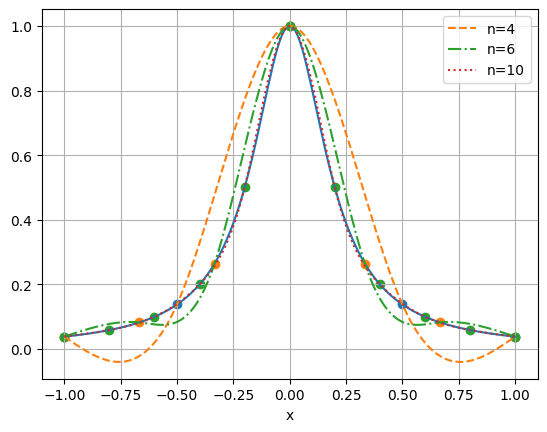

In [44]:
a = -1.0
b = 1.0
m = 200
x1 = np.linspace(a, b, m)
y1 = f(x1)
plt.plot(x1, y1)
nList = [4, 6, 10]
sglist = ['--', '-.', ':']
for k in range(len(nList)):
    n = nList[k]
    x = np.linspace(a, b, n + 1)
    y = f(x)
    plt.scatter(x, y, marker='o')
    c = coeff(x, y)
    for i in range(m):
        y1[i] = spline(x, y, c, x1[i])
    plt.plot(x1, y1, sglist[k], label=f"n={n}")
plt.xlabel('x')
plt.grid(True)
plt.legend()
